In [1]:
# ============================================================
# PROJECT 01 - E-commerce Subscription Analytics
# Cell 1: Imports & Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")

Dataset loaded successfully.
Shape: 7043 rows x 21 columns

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [2]:
# ============================================================
# Cell 2: Data Quality & Exploratory Analysis
# ============================================================

# Basic info
print("=== DATA TYPES & NULL VALUES ===")
print(df.dtypes)
print(f"\nNull values per column:")
print(df.isnull().sum())

# Fix TotalCharges (loaded as string, should be numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with null TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert SeniorCitizen to readable format
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Convert tenure to segments
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-60 months', '61-72 months']
)

print("\n=== CLEANED DATASET ===")
print(f"Shape after cleaning: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

=== DATA TYPES & NULL VALUES ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract  

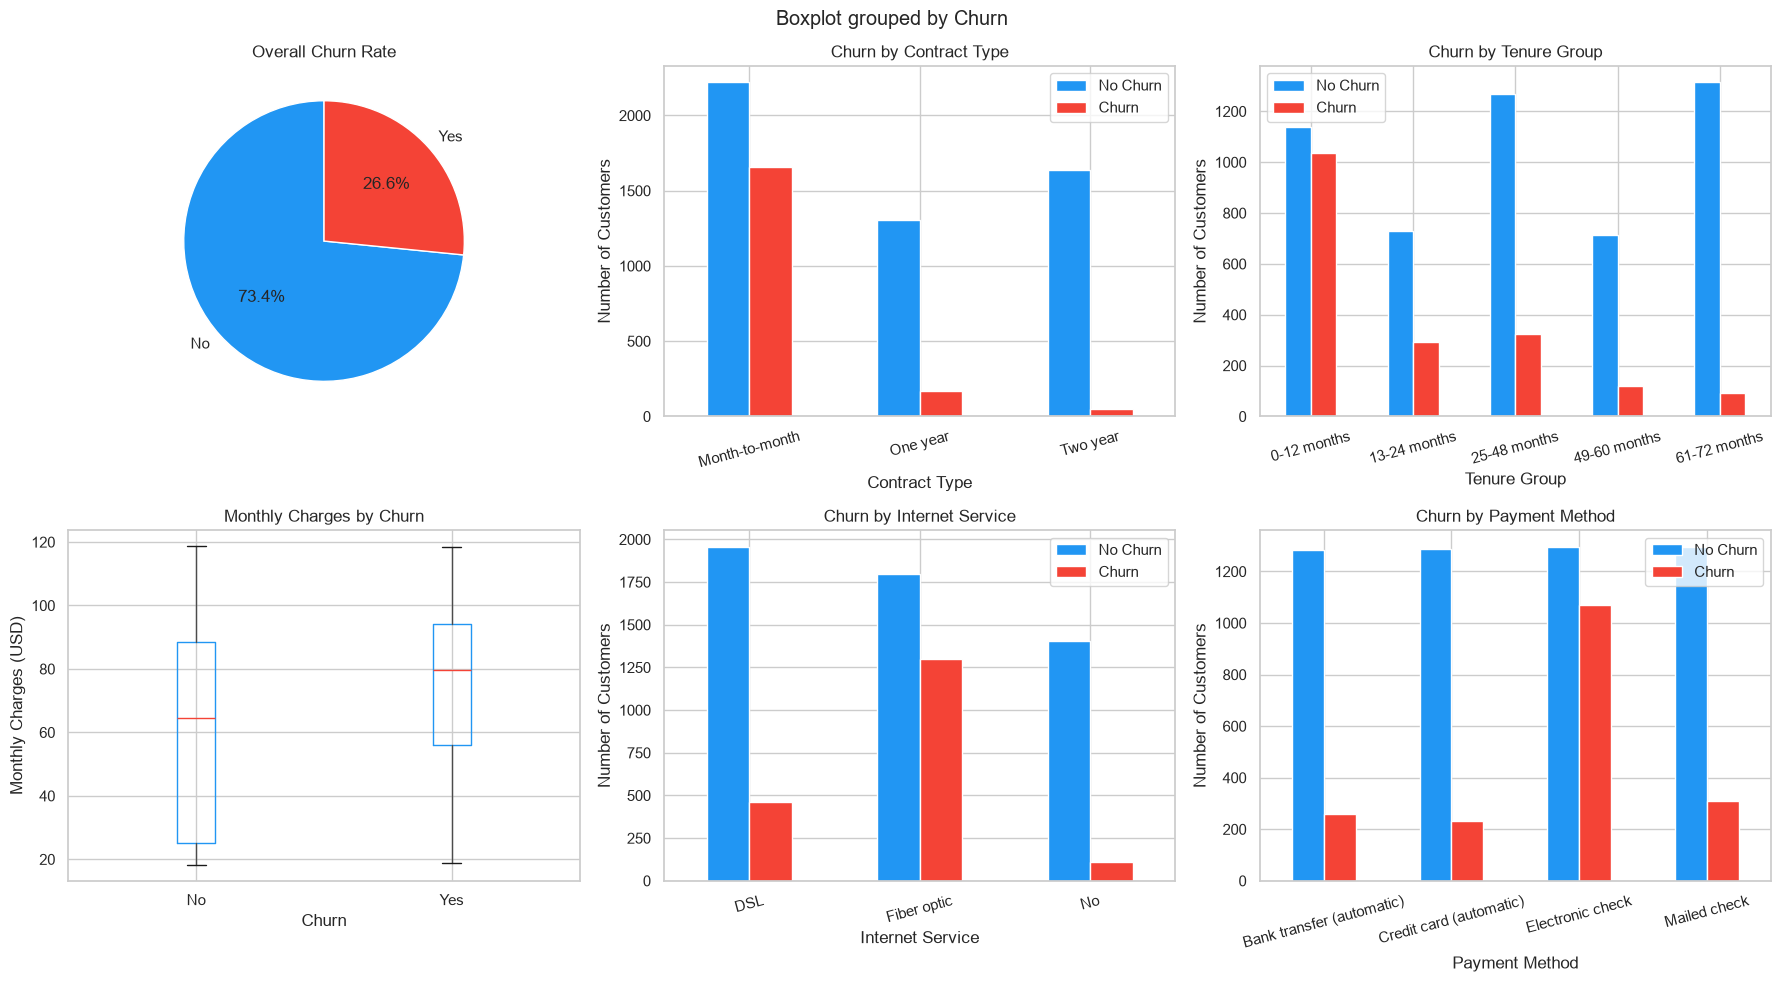

Chart saved as churn_analysis.png


In [3]:
# ============================================================
# Cell 3: Churn Distribution Visualizations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Subscription Analytics - Churn Analysis', fontsize=16, fontweight='bold')

# 1. Overall churn rate
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#F44336'],
    startangle=90
)
axes[0, 0].set_title('Overall Churn Rate')

# 2. Churn by contract type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0, 1], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0, 1].set_title('Churn by Contract Type')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend(['No Churn', 'Churn'])

# 3. Churn by tenure group
tenure_churn = df.groupby(['tenure_group', 'Churn']).size().unstack()
tenure_churn.plot(kind='bar', ax=axes[0, 2], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0, 2].set_title('Churn by Tenure Group')
axes[0, 2].set_xlabel('Tenure Group')
axes[0, 2].set_ylabel('Number of Customers')
axes[0, 2].tick_params(axis='x', rotation=15)
axes[0, 2].legend(['No Churn', 'Churn'])

# 4. Monthly charges distribution
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 0], 
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='#F44336'))
axes[1, 0].set_title('Monthly Charges by Churn')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Monthly Charges (USD)')

# 5. Churn by internet service
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[1, 1], color=['#2196F3', '#F44336'], edgecolor='white')
axes[1, 1].set_title('Churn by Internet Service')
axes[1, 1].set_xlabel('Internet Service')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(['No Churn', 'Churn'])

# 6. Churn by payment method
payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack()
payment_churn.plot(kind='bar', ax=axes[1, 2], color=['#2196F3', '#F44336'], edgecolor='white')
axes[1, 2].set_title('Churn by Payment Method')
axes[1, 2].set_xlabel('Payment Method')
axes[1, 2].set_ylabel('Number of Customers')
axes[1, 2].tick_params(axis='x', rotation=15)
axes[1, 2].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as churn_analysis.png")

In [4]:
# ============================================================
# Cell 4: Churn Prediction Model (Machine Learning)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare features
df_model = df.drop(columns=['customerID', 'tenure_group'])

# Encode categorical variables
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Target variable
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("\n=== LOGISTIC REGRESSION ===")
print(f"AUC-ROC: {lr_auc:.4f}")
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

print("\n=== RANDOM FOREST ===")
print(f"AUC-ROC: {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

Training set: 5625 rows
Test set:     1407 rows

=== LOGISTIC REGRESSION ===
AUC-ROC: 0.8346
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


=== RANDOM FOREST ===
AUC-ROC: 0.8113
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



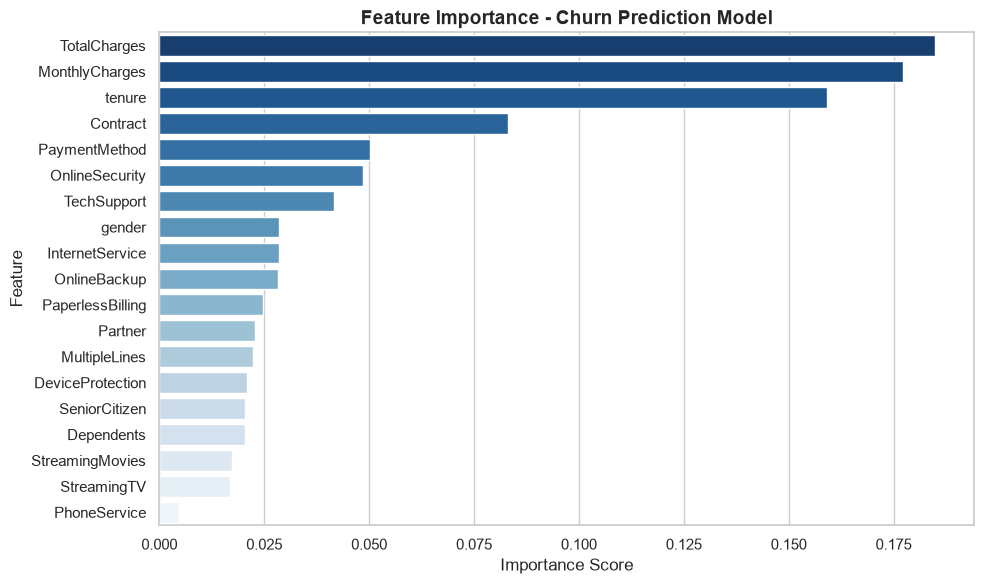

Chart saved as feature_importance.png

Dataset exported to subscription_analytics.xlsx

Churn risk distribution:
churn_risk
Low Risk       3834
High Risk      1681
Medium Risk     408
Name: count, dtype: int64

=== KEY BUSINESS METRICS ===
Total customers:        7,032


ValueError: Cannot specify ',' with 's'.

In [5]:
# ============================================================
# Cell 5: Feature Importance & Export for Power BI
# ============================================================

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature',
    palette='Blues_r',
    ax=ax
)
ax.set_title('Feature Importance - Churn Prediction Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as feature_importance.png")

# Add churn probability to original dataframe
df['churn_probability'] = rf_model.predict_proba(
    df_model.drop(columns=['Churn'])
)[:, 1]

# Add risk segment
df['churn_risk'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Export to Excel for Power BI
df.to_excel('subscription_analytics.xlsx', index=False)
print("\nDataset exported to subscription_analytics.xlsx")
print(f"\nChurn risk distribution:")
print(df['churn_risk'].value_counts())

# Summary statistics
print("\n=== KEY BUSINESS METRICS ===")
print(f"Total customers:        {len(df):,}")
print(f"Churned customers:      {df['Churn'].sum():,}")
print(f"Churn rate:             {df['Churn'].mean():.1%}")
print(f"Avg monthly charges:    USD {df['MonthlyCharges'].mean():.2f}")
print(f"Avg tenure:             {df['tenure'].mean():.1f} months")
print(f"High risk customers:    {(df['churn_risk'] == 'High Risk').sum():,}")

00:20:01 - cmdstanpy - INFO - Chain [1] start processing
00:20:02 - cmdstanpy - INFO - Chain [1] done processing


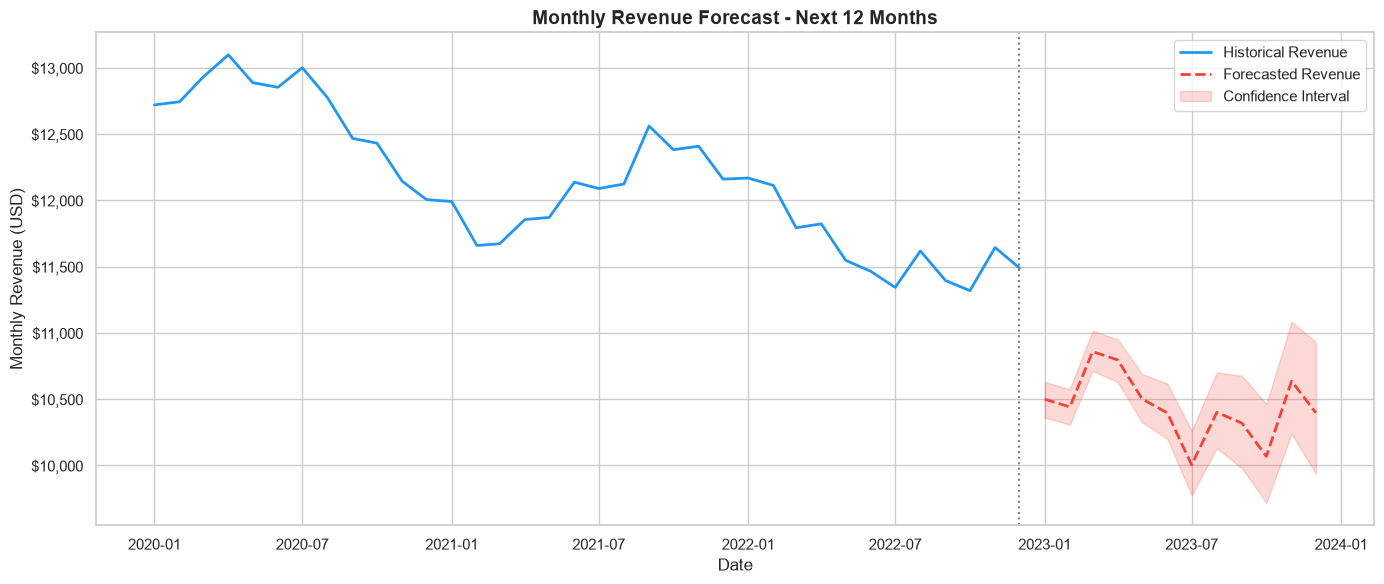

Forecast saved as revenue_forecast.png
Forecast data exported to revenue_forecast.xlsx

=== FORECAST SUMMARY (Next 12 months) ===
Average monthly revenue: USD 10,443.47
Min forecast:            USD 10,003.73
Max forecast:            USD 10,859.13


In [6]:
# ============================================================
# Cell 6: Revenue Forecasting with Prophet
# ============================================================

from prophet import Prophet

# Simulate monthly revenue time series from dataset
np.random.seed(42)
months = pd.date_range(start='2020-01-01', periods=36, freq='MS')

base_revenue = df['MonthlyCharges'].sum() / 36
churn_impact = np.linspace(0, -0.08, 36)
seasonality = np.sin(np.linspace(0, 4 * np.pi, 36)) * 0.03
noise = np.random.normal(0, 0.01, 36)

revenue = base_revenue * (1 + churn_impact + seasonality + noise)

# Build Prophet dataframe
prophet_df = pd.DataFrame({
    'ds': months,
    'y': revenue
})

# Train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(prophet_df)

# Forecast next 12 months
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Plot forecast
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prophet_df['ds'], prophet_df['y'], 
        color='#2196F3', linewidth=2, label='Historical Revenue')
ax.plot(forecast['ds'].tail(12), forecast['yhat'].tail(12), 
        color='#F44336', linewidth=2, linestyle='--', label='Forecasted Revenue')
ax.fill_between(
    forecast['ds'].tail(12),
    forecast['yhat_lower'].tail(12),
    forecast['yhat_upper'].tail(12),
    alpha=0.2, color='#F44336', label='Confidence Interval'
)
ax.axvline(x=prophet_df['ds'].max(), color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Monthly Revenue Forecast - Next 12 Months', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Revenue (USD)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Export forecast to Excel
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12).to_excel(
    'revenue_forecast.xlsx', index=False
)

print("Forecast saved as revenue_forecast.png")
print("Forecast data exported to revenue_forecast.xlsx")
print(f"\n=== FORECAST SUMMARY (Next 12 months) ===")
forecast_next = forecast.tail(12)
print(f"Average monthly revenue: USD {forecast_next['yhat'].mean():,.2f}")
print(f"Min forecast:            USD {forecast_next['yhat'].min():,.2f}")
print(f"Max forecast:            USD {forecast_next['yhat'].max():,.2f}")